### O gym 0.26 (mais atual) tem parametros diferentes comparado ao do instrutor (next_state, reward, done, info = streets.step(action)), por isso decidi fazer um downgrade para a versao dele (0.12.5) e deu certo!

In [2]:
import gym
import random

random.seed(1234)
# gera os mesmos numeros 

streets = gym.make("Taxi-v2").env
# mega o modelo de jogo com regras Taxi
streets.reset()
print(streets.render())

+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

None


In [3]:
initial_state=streets.encode(2,3,2,0)
streets.s = initial_state
print(streets.render())

+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

None


In [4]:
streets.P[initial_state]

{0: [(1.0, 368, -1, False)],
 1: [(1.0, 168, -1, False)],
 2: [(1.0, 288, -1, False)],
 3: [(1.0, 248, -1, False)],
 4: [(1.0, 268, -10, False)],
 5: [(1.0, 268, -10, False)]}

In [5]:
import numpy as np

q_table = np.zeros([streets.observation_space.n, streets.action_space.n])
# tabela de que representa todos os estado e acoes possiveis no jogo
learning_rate = 0.1
#velocidade de aprendizado
discount_factor = 0.6
# fator de desconto
exploration = 0.1
epochs = 10000
# quantas vezes sera feito o treino 

#conta quantos passos foram dados em cada epoca
steps_ep = []

for taxi_run in range(epochs):
    state = streets.reset()
    #estado inicial
    done = False
    steps=0
    
    while not done:
        random_value = random.uniform(0,1)
        # sorteia um numero entre 0 e 1 e depois verifica se esse numero for menor que o fato de expçoração
        if(random_value < exploration):
            action = streets.action_space.sample()
            #explora uma açao nova aleatoria
        else:
            action = np.argmax(q_table[state])
            #pega uma  acao da tabela 
        
        next_state, reward, done, info = streets.step(action)
        # retorna o estado, a recompensa, se a entrega foi feita
        
        prev_q = q_table[state, action]
        # pega o valor q atual na tabela
        next_max_q = np.max(q_table[next_state])
        # pega o maior valor das acoes possiveis a partir do proximo estado
        new_q =(1 - learning_rate) * prev_q +learning_rate * (reward +discount_factor * next_max_q)
        # pega o que ja sabia antes e o que aprendeu
        q_table[state,action] = new_q
        # salva o novo valor na tabela
        
        state = next_state
        # pula para o proximo estado
        steps+=1
        # contador de passos
    steps_ep.append(steps)
    #adiciona na lista de passos por epoca

In [6]:
q_table[initial_state]

array([-2.39688416, -2.390411  , -2.41243095, -2.3639511 , -6.35985514,
       -8.08245644])

In [7]:
from IPython.display import clear_output
from time import sleep

for tripnum in range(1,11):
    state= streets.reset()
    
    done = False
    
    while not done:
        action = np.argmax(q_table[state])
        next_state, reward, done, info = streets.step(action)
        clear_output(wait=True)
        print("Trip number " + str(tripnum))
        print(streets.render(mode ='ansi'))
        sleep(.5)
        state = next_state
    sleep(2)
# passa por 10 viagens, faz o jogo visual para que seja mais facil de entender

Trip number 2
+---------+
|R: | : :G|
| : : : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



KeyboardInterrupt: 

In [46]:
steps_ep
# lista de passos por epoca

[545,
 484,
 588,
 891,
 580,
 926,
 405,
 1195,
 650,
 938,
 1054,
 735,
 349,
 1119,
 956,
 523,
 711,
 590,
 835,
 679,
 377,
 980,
 224,
 722,
 787,
 458,
 376,
 562,
 281,
 273,
 362,
 305,
 343,
 278,
 642,
 375,
 804,
 512,
 267,
 163,
 563,
 250,
 577,
 577,
 185,
 100,
 349,
 87,
 308,
 225,
 321,
 86,
 674,
 165,
 350,
 142,
 528,
 428,
 534,
 256,
 512,
 149,
 330,
 365,
 455,
 472,
 463,
 208,
 201,
 110,
 182,
 142,
 305,
 147,
 243,
 239,
 383,
 257,
 107,
 249,
 229,
 202,
 323,
 354,
 284,
 110,
 144,
 185,
 311,
 12,
 291,
 372,
 181,
 448,
 48,
 157,
 110,
 448,
 380,
 292,
 262,
 86,
 356,
 12,
 97,
 222,
 208,
 294,
 92,
 77,
 260,
 399,
 117,
 314,
 118,
 767,
 231,
 94,
 108,
 178,
 107,
 9,
 54,
 198,
 74,
 100,
 393,
 309,
 131,
 201,
 202,
 149,
 232,
 203,
 146,
 229,
 162,
 208,
 479,
 129,
 178,
 157,
 65,
 151,
 240,
 166,
 204,
 217,
 84,
 172,
 176,
 301,
 270,
 124,
 56,
 210,
 260,
 124,
 106,
 137,
 125,
 145,
 237,
 167,
 123,
 189,
 188,
 42,
 169,
 

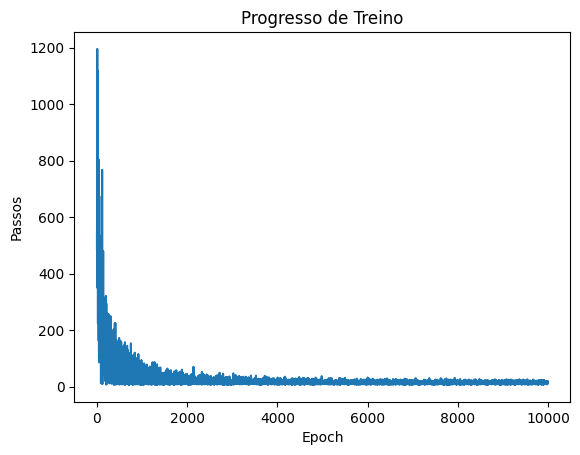

In [47]:
import matplotlib.pyplot as plt

plt.plot(steps_ep)
plt.xlabel('Epoch')
plt.ylabel('Passos')
plt.title('Progresso de Treino')
plt.savefig('progresso_treino.png', dpi=300, bbox_inches='tight')

plt.show()